# 01 — LGBM: Joint MODEL_GRID + Feature-Selection Search · M1Y WFO · Long+Short (with fees)

**What this notebook does**
- Walk-forward (sliding 1-year, monthly step) LightGBM probability model, consistent fee model.
- **Joint search** over a *feature-selection* grid (`top_n_features`, `corr_threshold`) and a
  *model* grid (`num_leaves`, `min_child_samples`, `learning_rate`) → 48 configurations.
- Feature selection = relevance–redundancy filter (univariate AUC → Spearman redundancy prune → top-N).
- For each config: WFO → OOS probs → exhaustive trading grid. Best config chosen by
  **grid-val Sharpe** (leak-free; selection never sees OOS) subject to a **≥120-trade floor** (prevents the near-dormant high-threshold configs
  that left an earlier configuration flat for months).
- Overwrites `artifacts/notebooks_v2/01_lgbm/` consumed by `04_meta_learning_v1`.

In [23]:
import calendar, itertools, json, time, warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
mpl.rcParams.update({
    'font.family':'serif','font.serif':['DejaVu Serif'],
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.labelsize':10,'axes.titlesize':11,'xtick.labelsize':9,'ytick.labelsize':9,
    'legend.fontsize':9,'figure.dpi':120,'savefig.dpi':200,'savefig.bbox':'tight',
})
ACCENT='#F7931A'; BLUE='#2962FF'; GREY='#9E9E9E'; RED='#EF5350'; GREEN='#26A69A'

def _repo_root():
    p = Path.cwd()
    while p != p.parent:
        if (p/'pyproject.toml').exists(): return p
        p = p.parent
    raise RuntimeError('pyproject.toml not found')

REPO     = _repo_root()
ARTS_DIR = REPO/'artifacts'/'notebooks_v2'/'01_lgbm'
ARTS_DIR.mkdir(parents=True, exist_ok=True)

# ── WFO / OOS (unified across notebooks_v2) ──────────────────────────
OOS_START      = pd.Timestamp('2024-06-01')
OOS_END        = pd.Timestamp('2026-05-31')   # inclusive upper bound (data ends 2026-05-16)
GRID_VAL_START = pd.Timestamp('2022-01-01')
GRID_VAL_END   = pd.Timestamp('2024-05-30')
TRAIN_WINDOW_H = 8760      # sliding 1-year window (M1Y)
STEP_SIZE      = 720       # monthly step
EMBARGO        = 12
VAL_FRAC       = 0.20
LABEL_COL      = 'label'

# ── Fee model (spot longs + futures shorts) ────────
MAKER_FEE=0.0000; SPOT_TAKER_FEE=0.0005; FUTURES_TAKER_FEE=0.0005
BUFFER=0.0005; SHORT_FUNDING_H=0.0000077

# ── Joint search grids ───────────────────────────────────────────────
MODEL_GRID = {
    'top_n_features':    [20, 35, 50],
    'corr_threshold':    [0.85, 0.90],
    'num_leaves':        [31, 63],
    'min_child_samples': [30, 50],
    'learning_rate':     [0.01, 0.02],
}
TRADING_GRID = {                      # exhaustive trading grid
    'long_threshold':  [0.55, 0.58, 0.60, 0.63],
    'short_threshold': [0.30, 0.35, 0.40],
    'entry_atr_mult':  [0.3, 0.6, 1.0],
    'sl_atr_mult':     [1.5, 2.0, 2.5],
    'tp_atr_mult':     [2.0, 2.5, 3.0],
    'min_sl':          [0.010, 0.015],
    'min_hold':        [4, 8],
    'max_hold':        [24, 48],
    'cooldown':        [2, 3],
}
LGBM_BASE = dict(max_depth=6, colsample_bytree=0.5, subsample=0.7,
                 reg_alpha=0.1, reg_lambda=1.0, n_estimators=500,
                 objective='binary', metric='auc', verbose=-1, random_state=0, n_jobs=-1)
MIN_TRADES_OOS = 120                  # >=60/yr over 2-yr OOS -> guarantees regular trading
EXCLUDE = {'open','high','low','close','volume', LABEL_COL,
           'sma_200','mkt_stablecoin_pct','mkt_total_mcap_chg_24h'}
_tkeys   = list(TRADING_GRID); _tcombos = list(itertools.product(*TRADING_GRID.values()))
_mkeys   = list(MODEL_GRID);   _mcombos = list(itertools.product(*MODEL_GRID.values()))
print(f'Model grid: {len(_mcombos)} configs  |  Trading grid: {len(_tcombos)} combos')
print(f'Selection: GRID-VAL Sharpe (leak-free), min_trades>={MIN_TRADES_OOS}  |  OOS {OOS_START.date()} → {OOS_END.date()}')

Model grid: 48 configs  |  Trading grid: 5184 combos
Selection: GRID-VAL Sharpe (leak-free), min_trades>=120  |  OOS 2024-06-01 → 2026-05-31


In [24]:
UNIFIED = REPO / 'data' / 'features' / 'BTCUSDT_1h_unified.parquet'
if not UNIFIED.exists():
    raise FileNotFoundError(f'{UNIFIED} not found — run 00_data_ingestion_v1.ipynb first.')
df = pd.read_parquet(UNIFIED)
df.index = df.index.tz_localize(None) if df.index.tz else df.index
oos_mask = df.index >= OOS_START
oos_df   = df[oos_mask].copy()

def build_candidate_pool(df):
    num = df.select_dtypes(include=[np.number]).columns
    pre = df[df.index < OOS_START]
    keep = []
    for c in num:
        if c in EXCLUDE: continue
        s = pre[c]
        if s.notna().sum() < 1000 or s.std(skipna=True) < 1e-9: continue
        keep.append(c)
    return keep

POOL = build_candidate_pool(df)
print(f'Unified parquet : {df.shape}  ({df.index.min().date()} → {df.index.max().date()})')
print(f'OOS bars        : {oos_mask.sum():,}  ({OOS_START.date()} → {df.index[-1].date()})')
print(f'Candidate pool  : {len(POOL)} features  |  Label dist {df[LABEL_COL].value_counts().to_dict()}')

Unified parquet : (74366, 292)  (2017-11-15 → 2026-05-16)
OOS bars        : 17,137  (2024-06-01 → 2026-05-16)
Candidate pool  : 282 features  |  Label dist {1: 37822, 0: 36544}


In [25]:
# ── Relevance–redundancy feature selection (filter family) ───────────────────
def rank_features(df, pool):
    pre = df[df.index < OOS_START]; y = pre[LABEL_COL].values
    auc = {}
    for c in pool:
        try: a = roc_auc_score(y, pre[c].fillna(0.0).values)
        except Exception: continue
        auc[c] = max(a, 1 - a)                       # direction-agnostic relevance
    survivors = sorted([c for c in pool if auc.get(c,0) > 0.502], key=lambda c: auc[c], reverse=True)
    X = pre[survivors].fillna(0.0).values
    rho = np.abs(np.atleast_2d(spearmanr(X)[0]))
    return survivors, auc, rho

def select_features(survivors, auc, rho, top_n, corr_threshold):
    idx = {c:i for i,c in enumerate(survivors)}; kept = []
    for c in survivors:                              # AUC-descending
        if all(rho[idx[c], idx[k]] <= corr_threshold for k in kept):
            kept.append(c)
        if len(kept) >= top_n: break
    return kept

SURV, AUC_, RHO = rank_features(df, POOL)
print(f'Survivors (AUC>0.502): {len(SURV)} / {len(POOL)}')
FSETS = {}
for ct in MODEL_GRID['corr_threshold']:
    for tn in MODEL_GRID['top_n_features']:
        FSETS[(ct,tn)] = select_features(SURV, AUC_, RHO, tn, ct)
        print(f'  corr<={ct}  top_n={tn:>2} -> {len(FSETS[(ct,tn)])} feats')

Survivors (AUC>0.502): 192 / 282
  corr<=0.85  top_n=20 -> 20 feats
  corr<=0.85  top_n=35 -> 35 feats
  corr<=0.85  top_n=50 -> 50 feats
  corr<=0.9  top_n=20 -> 20 feats
  corr<=0.9  top_n=35 -> 35 feats
  corr<=0.9  top_n=50 -> 50 feats


In [26]:
# ── Walk-forward (sliding 1-year window, monthly step) ───────────────────────
def run_m1y_wfo(df, feats, num_leaves, min_child_samples, learning_rate, verbose=False):
    n = len(df); probs = np.full(n, np.nan); i = 0; last = None
    params = dict(LGBM_BASE, num_leaves=num_leaves,
                  min_child_samples=min_child_samples, learning_rate=learning_rate)
    Xall = df[feats].fillna(0).values; yall = df[LABEL_COL].values
    while i < n:
        tr_end = i; tr_start = max(0, tr_end - TRAIN_WINDOW_H)
        if tr_start >= tr_end - 100: i += STEP_SIZE; continue
        val_n = max(50, int((tr_end - tr_start) * VAL_FRAC))
        X_tr, y_tr = Xall[tr_start:tr_end-val_n], yall[tr_start:tr_end-val_n]
        X_va, y_va = Xall[tr_end-val_n:tr_end],   yall[tr_end-val_n:tr_end]
        if len(np.unique(y_tr)) < 2: i += STEP_SIZE; continue
        mdl = lgb.LGBMClassifier(**params)
        mdl.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],
                callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
        oos_end = min(i+STEP_SIZE, n); oos_emb = min(i+EMBARGO, oos_end)
        if oos_end > oos_emb: probs[oos_emb:oos_end] = mdl.predict_proba(Xall[oos_emb:oos_end])[:,1]
        last = mdl; i += STEP_SIZE
    return pd.Series(probs, index=df.index, name='p_up'), last

In [27]:
# ── Backtest + metrics + regime definitions ──────────────────
def _run_backtest(probs_arr, close_arr, high_arr, low_arr, atr_arr,
        long_threshold, short_threshold, entry_atr_mult, sl_atr_mult, tp_atr_mult,
        min_sl, min_hold, max_hold, cooldown, with_fees=True):
    n=len(close_arr); eq=np.ones(n); cur=1.0; trades=[]
    in_pos=False; direction=None; entry_px=sl_px=tp_px=pos_eq=entry_fee=0.0
    hold_cnt=cd_cnt=0; funding=0.0; pending=None
    for i in range(n):
        lo=low_arr[i]; hi=high_arr[i]; px=close_arr[i]
        if in_pos:
            hold_cnt+=1
            if direction=='short': funding+=SHORT_FUNDING_H
            eq[i]=pos_eq*(px/entry_px if direction=='long' else 1+(entry_px-px)/entry_px)
            exited=False; exit_px=0.0; reason=''; exit_fee=0.0
            if hold_cnt>=min_hold:
                if direction=='long':
                    if lo<=sl_px: exit_px=sl_px;exited=True;reason='sl';exit_fee=SPOT_TAKER_FEE if with_fees else 0.
                    elif hi>=tp_px: exit_px=tp_px;exited=True;reason='tp';exit_fee=MAKER_FEE
                    elif hold_cnt>=max_hold: exit_px=px;exited=True;reason='timeout';exit_fee=SPOT_TAKER_FEE if with_fees else 0.
                else:
                    if hi>=sl_px: exit_px=sl_px;exited=True;reason='sl';exit_fee=FUTURES_TAKER_FEE if with_fees else 0.
                    elif lo<=tp_px: exit_px=tp_px;exited=True;reason='tp';exit_fee=MAKER_FEE
                    elif hold_cnt>=max_hold: exit_px=px;exited=True;reason='timeout';exit_fee=FUTURES_TAKER_FEE if with_fees else 0.
            if exited:
                gross=((exit_px-entry_px)/entry_px if direction=='long' else (entry_px-exit_px)/entry_px)
                net=gross-(entry_fee+exit_fee if with_fees else 0.)+funding
                cur=pos_eq*(1.+net); eq[i]=cur
                trades.append({'direction':direction,'reason':reason,'gross':gross,'net':net,'hold':hold_cnt})
                in_pos=False; cd_cnt=cooldown; funding=0.
        elif pending is not None:
            d,lim,p_sl,p_tp=pending
            if d=='long': filled=lo<=lim+BUFFER; ef=MAKER_FEE if (filled and with_fees) else (SPOT_TAKER_FEE if with_fees else 0.)
            else: filled=hi>=lim-BUFFER; ef=MAKER_FEE if (filled and with_fees) else (FUTURES_TAKER_FEE if with_fees else 0.)
            entry_px=lim if filled else px; sl_px=p_sl; tp_px=p_tp; entry_fee=ef
            direction=d; in_pos=True; pos_eq=cur; hold_cnt=0; funding=0.; pending=None; eq[i]=cur
        elif cd_cnt>0: cd_cnt-=1; eq[i]=cur
        elif not np.isnan(probs_arr[i]) and i+1<n:
            atr=max(atr_arr[i],min_sl)
            if probs_arr[i]>long_threshold:
                pending=('long',px*(1-entry_atr_mult*atr),px*(1-sl_atr_mult*atr),px*(1+tp_atr_mult*atr))
            elif probs_arr[i]<short_threshold:
                pending=('short',px*(1+entry_atr_mult*atr),px*(1+sl_atr_mult*atr),px*(1-tp_atr_mult*atr))
            eq[i]=cur
        else: eq[i]=cur
    if in_pos:
        gross=((px-entry_px)/entry_px if direction=='long' else (entry_px-px)/entry_px)
        taker=SPOT_TAKER_FEE if direction=='long' else FUTURES_TAKER_FEE
        net=gross-(entry_fee+(taker if with_fees else 0.))+funding; cur=pos_eq*(1.+net); eq[-1]=cur
    return eq, trades

def _sharpe(eq):
    r=np.diff(np.log(np.maximum(eq,1e-12))); return float(r.mean()/(r.std(ddof=1)+1e-12)*np.sqrt(24*365))
def _maxdd(eq):
    pk=np.maximum.accumulate(eq); return float(((eq-pk)/(pk+1e-12)).min())
def _sortino(eq):
    r=np.diff(np.log(np.maximum(eq,1e-12))); neg=r[r<0]
    d=neg.std(ddof=1) if len(neg)>1 else 1e-12
    return float(r.mean()/(d+1e-12)*np.sqrt(24*365))

REGIME_CHOP=(pd.Timestamp('2024-06-01'),pd.Timestamp('2024-11-05'))
REGIME_BULL=(pd.Timestamp('2024-11-06'),pd.Timestamp('2025-10-31'))
REGIME_BEAR=(pd.Timestamp('2025-11-01'),pd.Timestamp('2026-05-31'))

def _regime_table(eq_arr, idx, close_arr):
    eq_s=pd.Series(eq_arr,index=idx); cl_s=pd.Series(close_arr,index=idx); rows=[]
    for label,(s,e) in [('Full OOS',(idx.min(),idx.max())),('Regime 1 — Chop',REGIME_CHOP),
                        ('Regime 2 — Bull',REGIME_BULL),('Regime 3 — Bear',REGIME_BEAR)]:
        m=(idx>=s)&(idx<=e)
        if m.sum()<24: continue
        seg=eq_s[m].values/eq_s[m].values[0]; bh=cl_s[m].values/cl_s[m].values[0]
        pk=np.maximum.accumulate(seg); dd=float(((seg-pk)/(pk+1e-12)).min())
        rows.append({'Period':label,'Bars':int(m.sum()),'Return':f'{seg[-1]-1:+.1%}',
                     'Sharpe':f'{_sharpe(seg):.3f}','Sortino':f'{_sortino(seg):.3f}','MaxDD':f'{dd:.1%}',
                     'BH_Ret':f'{bh[-1]-1:+.1%}','Alpha':f'{seg[-1]-bh[-1]:+.1%}'})
    return pd.DataFrame(rows).set_index('Period')

def trading_grid_on(probs, sub, min_trades):
    pa=probs.values; cl=sub['close'].values; hi=sub['high'].values
    lo=sub['low'].values; at=sub['atr_14_pct'].values; best=None
    for vals in _tcombos:
        p=dict(zip(_tkeys,vals))
        if p['short_threshold']>=p['long_threshold'] or p['max_hold']<p['min_hold']: continue
        eq,tr=_run_backtest(pa,cl,hi,lo,at,with_fees=True,**p)
        if len(tr)<min_trades: continue
        sh=_sharpe(eq)
        if best is None or sh>best['sharpe']:
            best={**p,'sharpe':sh,'total_ret':float(eq[-1]-1),'maxdd':_maxdd(eq),
                  'win_rate':float(np.mean([t['net']>0 for t in tr])),'n_trades':len(tr)}
    return best
print('Backtest + selection utilities ready.')

Backtest + selection utilities ready.


In [ ]:
# ── JOINT SEARCH (LEAK-FREE): select model + trading rule on the GRID-VAL window ──
# Selection NEVER sees the OOS window. The trading grid and the model config are both
# chosen to maximise GRID-VAL Sharpe (2022-01-01 → 2024-05-30). OOS is scored once,
# untouched, in the next cell. (Previously selection used OOS Sharpe → look-ahead, which
# made the winner unstable and the reported return optimistic.)
gv_mask = (df.index >= GRID_VAL_START) & (df.index <= GRID_VAL_END)
gv_df   = df[gv_mask].copy()
MIN_TRADES_GV = 120

rows=[]; best_overall=None; t0=time.time()
for ci,mc in enumerate(_mcombos):
    m=dict(zip(_mkeys,mc)); feats=FSETS[(m['corr_threshold'],m['top_n_features'])]
    probs,last=run_m1y_wfo(df,feats,m['num_leaves'],m['min_child_samples'],m['learning_rate'])
    # ── selection metrics: GRID-VAL only ──
    gp=probs[gv_mask]; gvalid=~np.isnan(gp.values)
    a_gv=roc_auc_score(gv_df[LABEL_COL].values[gvalid], gp.values[gvalid]) if gvalid.sum() else float('nan')
    bt=trading_grid_on(gp, gv_df, MIN_TRADES_GV)
    # ── report-only OOS AUC (NOT used for selection) ──
    op=probs[oos_mask]; ovalid=~np.isnan(op.values)
    a_oos=roc_auc_score(oos_df[LABEL_COL].values[ovalid], op.values[ovalid]) if ovalid.sum() else float('nan')
    if bt is None:
        print(f'[{ci+1}/48] {m} gvAUC={a_gv:.4f}  no >= {MIN_TRADES_GV}-trade config on grid-val'); continue
    rows.append({**m,'gv_auc':a_gv,'oos_auc':a_oos,**{f'tr_{k}':v for k,v in bt.items()}})
    if best_overall is None or bt['sharpe']>best_overall['bt']['sharpe']:
        best_overall=dict(m=m,bt=bt,auc=a_oos,gv_auc=a_gv,feats=feats,probs=probs,last=last)
    print(f"[{ci+1}/48] lr={m['learning_rate']} nl={m['num_leaves']} mcs={m['min_child_samples']} "
          f"N={m['top_n_features']} rho={m['corr_threshold']} | gvAUC={a_gv:.4f} oosAUC={a_oos:.4f} "
          f"gvSharpe={bt['sharpe']:.3f} gvRet={bt['total_ret']:+.1%} T={bt['n_trades']}")
leaderboard=pd.DataFrame(rows).sort_values('tr_sharpe',ascending=False).reset_index(drop=True)
print(f'\nSearch done in {(time.time()-t0)/60:.1f} min  |  {len(leaderboard)} valid configs (selected on GRID-VAL)')

# Promote the winner (chosen on grid-val) to module globals used downstream
BEST_MODEL = best_overall['m']
SELECTED_FEATURES = best_overall['feats']
BEST = {k:(int(best_overall['bt'][k]) if k in {'min_hold','max_hold','cooldown'} else best_overall['bt'][k]) for k in _tkeys}
all_probs  = best_overall['probs']
last_model = best_overall['last']
auc_oos    = best_overall['auc']
oos_probs  = all_probs[oos_mask]
print('\n=== BEST CONFIG (selected on grid-val, NOT OOS) ===')
print('model  :', BEST_MODEL); print('feats  :', len(SELECTED_FEATURES)); print('trading:', BEST)
print('grid-val Sharpe {:.3f} | grid-val AUC {:.4f} | OOS AUC {:.4f} (report-only)'.format(
      best_overall['bt']['sharpe'], best_overall['gv_auc'], best_overall['auc']))
print(leaderboard.head(8).to_string())

[1/48] lr=0.01 nl=31 mcs=30 N=20 rho=0.85 | gvAUC=0.5528 oosAUC=0.5347 gvSharpe=0.818 gvRet=+42.0% T=131
[2/48] lr=0.02 nl=31 mcs=30 N=20 rho=0.85 | gvAUC=0.5573 oosAUC=0.5350 gvSharpe=1.859 gvRet=+156.8% T=272
[3/48] lr=0.01 nl=31 mcs=50 N=20 rho=0.85 | gvAUC=0.5524 oosAUC=0.5358 gvSharpe=1.236 gvRet=+97.2% T=182
[4/48] lr=0.02 nl=31 mcs=50 N=20 rho=0.85 | gvAUC=0.5568 oosAUC=0.5346 gvSharpe=1.750 gvRet=+191.5% T=376
[5/48] lr=0.01 nl=63 mcs=30 N=20 rho=0.85 | gvAUC=0.5539 oosAUC=0.5344 gvSharpe=0.901 gvRet=+56.6% T=123
[6/48] lr=0.02 nl=63 mcs=30 N=20 rho=0.85 | gvAUC=0.5568 oosAUC=0.5371 gvSharpe=2.087 gvRet=+158.6% T=238
[7/48] lr=0.01 nl=63 mcs=50 N=20 rho=0.85 | gvAUC=0.5523 oosAUC=0.5343 gvSharpe=0.652 gvRet=+30.7% T=150
[8/48] lr=0.02 nl=63 mcs=50 N=20 rho=0.85 | gvAUC=0.5582 oosAUC=0.5317 gvSharpe=1.394 gvRet=+131.9% T=376
[9/48] lr=0.01 nl=31 mcs=30 N=20 rho=0.9 | gvAUC=0.5597 oosAUC=0.5347 gvSharpe=0.963 gvRet=+42.1% T=142
[10/48] lr=0.02 nl=31 mcs=30 N=20 rho=0.9 | gvAUC=0.

In [ ]:
# ── Final OOS backtest (best config), with-fees + zero-fee upper bound ───────
eq_fees,tdf_fees=_run_backtest(oos_probs.values, oos_df['close'].values, oos_df['high'].values,
    oos_df['low'].values, oos_df['atr_14_pct'].values, with_fees=True, **BEST)
eq_0fee,tdf_0fee=_run_backtest(oos_probs.values, oos_df['close'].values, oos_df['high'].values,
    oos_df['low'].values, oos_df['atr_14_pct'].values, with_fees=False, **BEST)
TF=pd.DataFrame(tdf_fees) if tdf_fees else pd.DataFrame(columns=['direction','reason','gross','net','hold'])
T0=pd.DataFrame(tdf_0fee) if tdf_0fee else pd.DataFrame(columns=['direction','reason','gross','net','hold'])
bh=(oos_df['close'].values/oos_df['close'].iloc[0]-1)*100; o_idx=oos_df.index
print(f'{"":22}{"Trades":>7}{"Win":>8}{"Return":>9}{"Sharpe":>8}{"MaxDD":>8}')
print('-'*62)
for lbl,eq,t in [('With fees',eq_fees,TF),('Zero-fee',eq_0fee,T0)]:
    wr=(t['net']>0).mean() if len(t) else 0
    nl=int((t['direction']=='long').sum()) if len(t) else 0
    ns=int((t['direction']=='short').sum()) if len(t) else 0
    print(f'{lbl:22}{len(t):>7}  {nl}L/{ns}S  {wr:>6.1%}{eq[-1]-1:>+9.1%}{_sharpe(eq):>8.3f}{_maxdd(eq):>8.1%}')
print(f'BTC Buy & Hold                               {bh[-1]:>+9.1f}%')

                       Trades     Win   Return  Sharpe   MaxDD
--------------------------------------------------------------
With fees                 123  79L/44S   48.8%   -12.9%  -0.357  -22.2%
Zero-fee                  123  79L/44S   49.6%    -5.0%  -0.132  -20.2%
BTC Buy & Hold                                   +16.9%


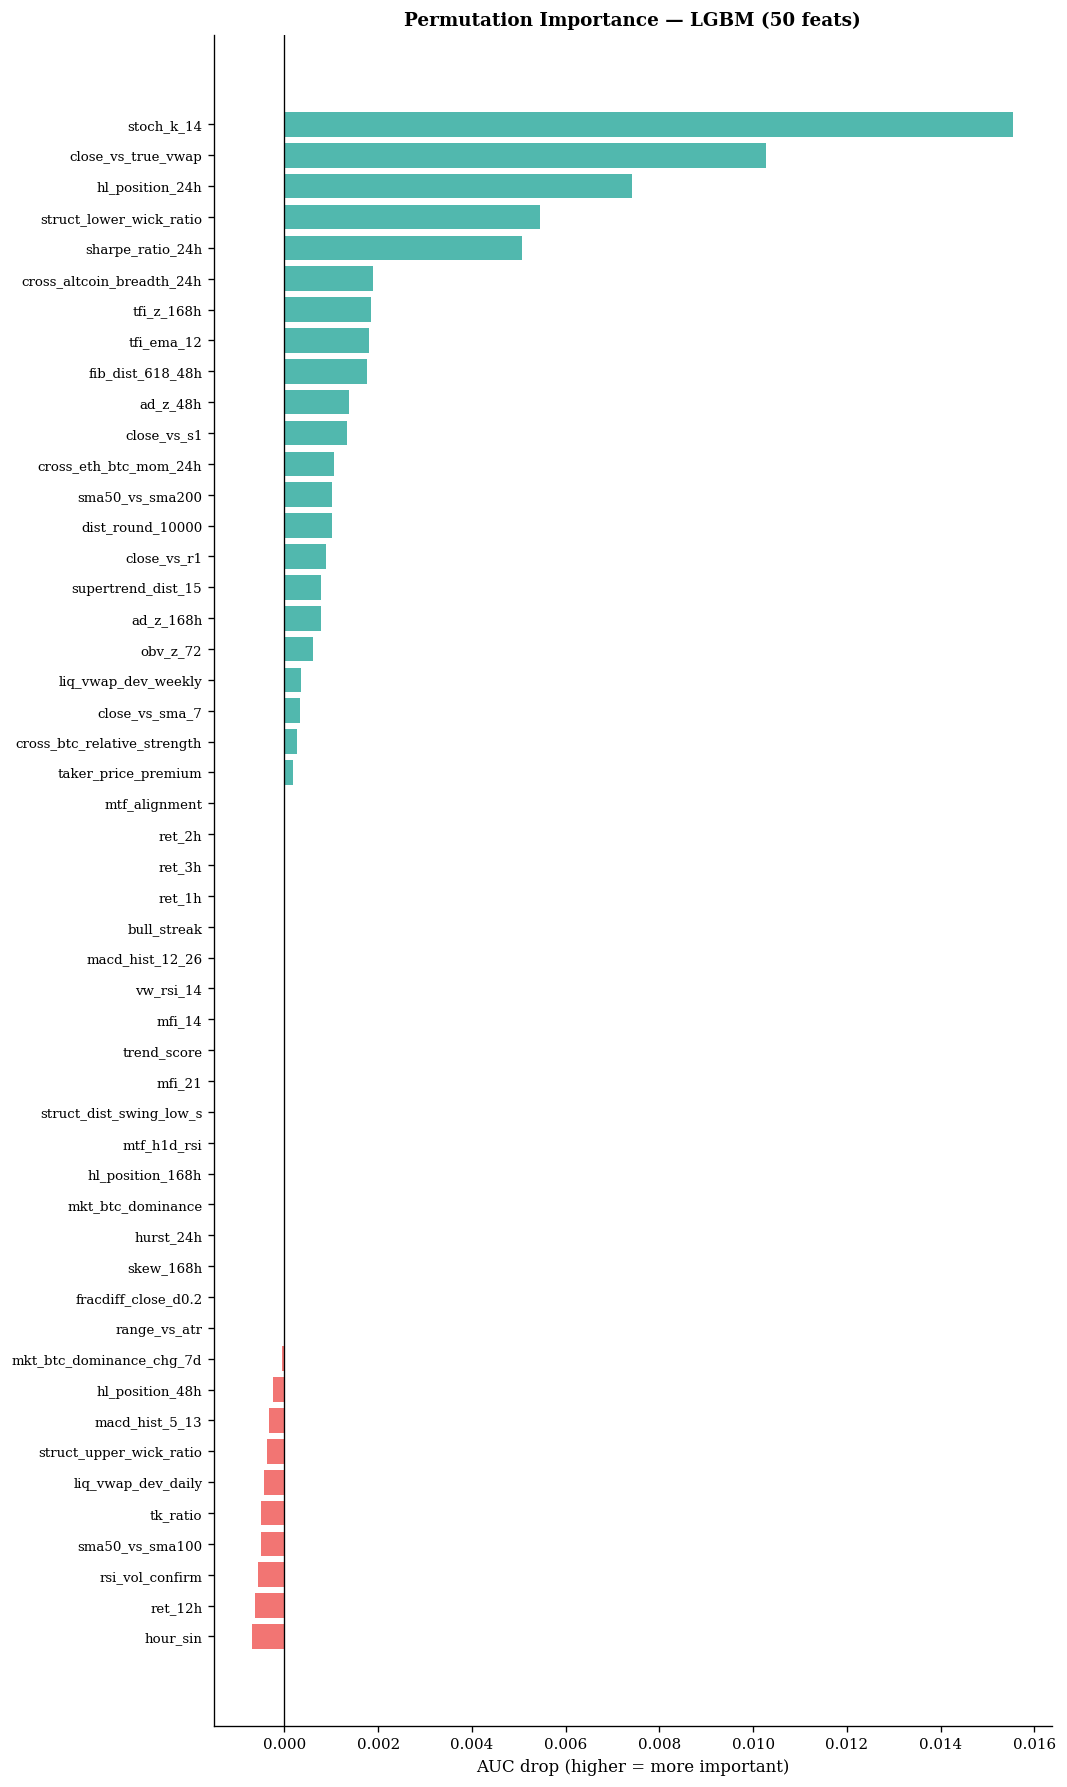

Top 10: ['stoch_k_14', 'close_vs_true_vwap', 'hl_position_24h', 'struct_lower_wick_ratio', 'sharpe_ratio_24h', 'cross_altcoin_breadth_24h', 'tfi_z_168h', 'tfi_ema_12', 'fib_dist_618_48h', 'ad_z_48h']


In [ ]:
# ── Permutation importance of the winning feature set (last fold) ────────────
imp_mask=(df.index>=pd.Timestamp('2022-01-01'))&(df.index<OOS_START)
X_imp=df[imp_mask][SELECTED_FEATURES].fillna(0).values; y_imp=df[imp_mask][LABEL_COL].values
base_auc=roc_auc_score(y_imp, last_model.predict_proba(X_imp)[:,1]); perm_imp={}
rng=np.random.default_rng(99)
for fi,feat in enumerate(SELECTED_FEATURES):
    drops=[]
    for _ in range(3):
        Xp=X_imp.copy(); rng.shuffle(Xp[:,fi])
        drops.append(base_auc-roc_auc_score(y_imp, last_model.predict_proba(Xp)[:,1]))
    perm_imp[feat]=float(np.mean(drops))
sf=sorted(perm_imp,key=perm_imp.get,reverse=True)
fig,ax=plt.subplots(figsize=(9,max(5,len(sf)*0.30)))
ax.barh(range(len(sf)),[perm_imp[f] for f in sf],color=[GREEN if perm_imp[f]>0 else RED for f in sf],alpha=0.8)
ax.set_yticks(range(len(sf))); ax.set_yticklabels(sf,fontsize=8); ax.invert_yaxis()
ax.axvline(0,color='k',lw=0.8); ax.set_xlabel('AUC drop (higher = more important)')
ax.set_title(f'Permutation Importance — LGBM ({len(sf)} feats)',fontweight='bold')
fig.tight_layout(); fig.savefig(ARTS_DIR/'01_perm_importance.png'); plt.show()
print('Top 10:', sf[:10])

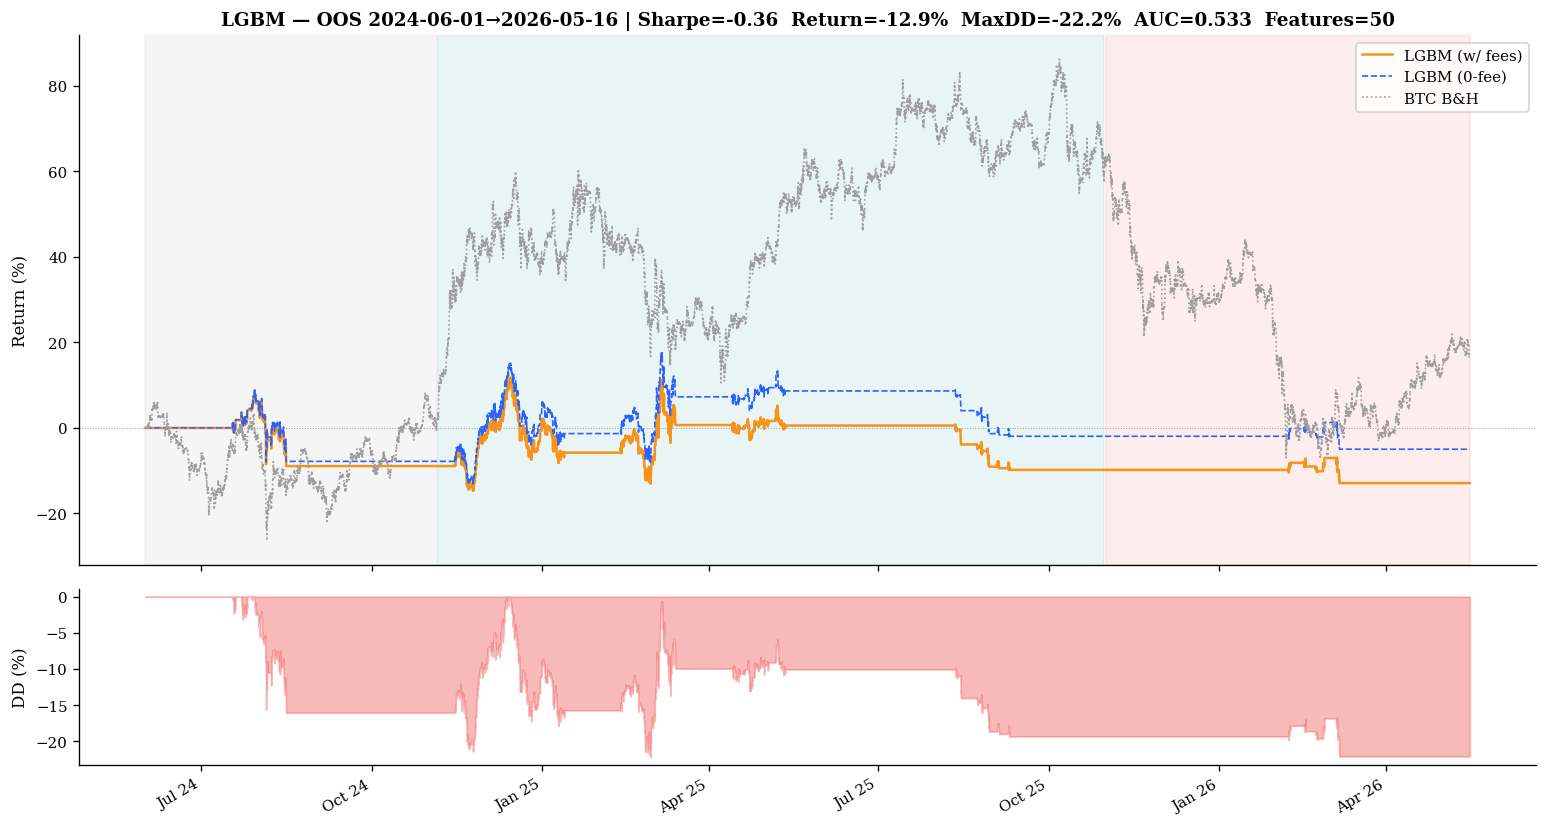

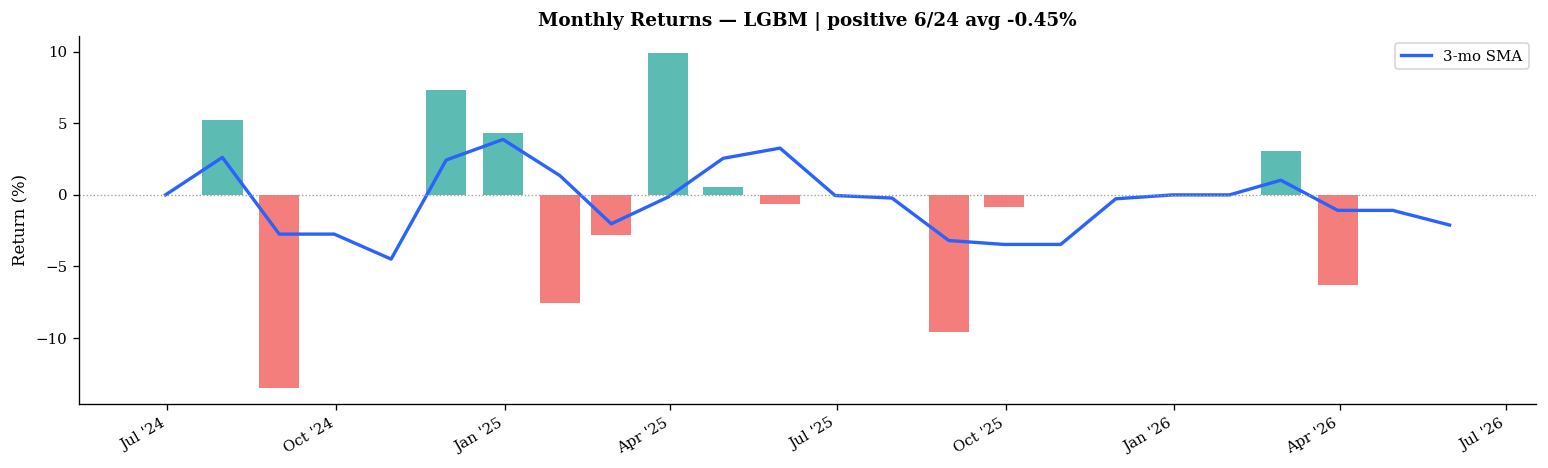

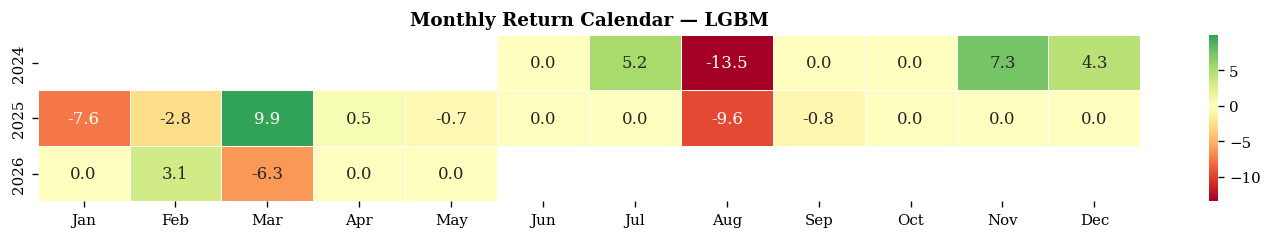

In [ ]:
# ── Equity + drawdown, monthly returns, calendar heatmap ─────────────────────
fig,(ax1,ax2)=plt.subplots(2,1,figsize=(13,7),height_ratios=[3,1],sharex=True)
ax1.plot(o_idx,(eq_fees-1)*100,color=ACCENT,lw=1.5,label='LGBM (w/ fees)')
ax1.plot(o_idx,(eq_0fee-1)*100,color=BLUE,lw=1.0,ls='--',label='LGBM (0-fee)')
ax1.plot(o_idx,bh,color=GREY,lw=1.0,ls=':',label='BTC B&H')
for rname,(rs,re),rc in [('Chop',REGIME_CHOP,'#9E9E9E'),('Bull',REGIME_BULL,'#26A69A'),('Bear',REGIME_BEAR,'#EF5350')]:
    ax1.axvspan(rs,min(re,o_idx[-1]),alpha=0.10,color=rc)
ax1.axhline(0,color=GREY,lw=0.6,ls=':'); ax1.set_ylabel('Return (%)'); ax1.legend()
ax1.set_title(f'LGBM — OOS {OOS_START.date()}→{o_idx[-1].date()} | '
    f'Sharpe={_sharpe(eq_fees):.2f}  Return={eq_fees[-1]-1:+.1%}  MaxDD={_maxdd(eq_fees):.1%}  '
    f'AUC={auc_oos:.3f}  Features={len(SELECTED_FEATURES)}',fontweight='bold')
pk=np.maximum.accumulate(eq_fees); dd=(eq_fees-pk)/pk*100
ax2.fill_between(o_idx,dd,0,color=RED,alpha=0.4); ax2.set_ylabel('DD (%)')
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
plt.setp(ax2.xaxis.get_majorticklabels(),rotation=30,ha='right')
fig.tight_layout(); fig.savefig(ARTS_DIR/'02_equity_drawdown.png'); plt.show()

eqs=pd.Series(eq_fees,index=o_idx); mret=eqs.resample('ME').last().pct_change().fillna(0)*100
fig,ax=plt.subplots(figsize=(13,4))
ax.bar(mret.index,mret.values,color=[GREEN if r>=0 else RED for r in mret],width=22,alpha=0.75)
ax.plot(mret.index,mret.rolling(3,min_periods=1).mean(),color=BLUE,lw=2,label='3-mo SMA')
ax.axhline(0,color=GREY,lw=0.8,ls=':'); ax.set_ylabel('Return (%)'); ax.legend()
ax.set_title(f'Monthly Returns — LGBM | positive {int((mret>0).sum())}/{len(mret)} avg {mret.mean():+.2f}%',fontweight='bold')
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
plt.setp(ax.xaxis.get_majorticklabels(),rotation=30,ha='right')
fig.tight_layout(); fig.savefig(ARTS_DIR/'03_monthly_returns.png'); plt.show()

cal=mret.to_frame('r'); cal['y']=cal.index.year; cal['m']=cal.index.month
piv=cal.pivot(index='y',columns='m',values='r'); piv.columns=[calendar.month_abbr[mm] for mm in piv.columns]
fig,ax=plt.subplots(figsize=(12,max(2,len(piv)*0.7)))
sns.heatmap(piv,ax=ax,cmap='RdYlGn',center=0,annot=True,fmt='.1f',linewidths=0.5)
ax.set_title('Monthly Return Calendar — LGBM',fontweight='bold'); ax.set_xlabel(''); ax.set_ylabel('')
fig.tight_layout(); fig.savefig(ARTS_DIR/'04_monthly_heatmap.png'); plt.show()

In [ ]:
# ── Save artifacts for the meta-learner ──────────────────────────────────────
np.save(ARTS_DIR/'oos_probs.npy', oos_probs.values.astype(np.float32))
np.save(ARTS_DIR/'oos_index.npy', oos_df.index.astype('datetime64[ns]').astype(np.int64).values)
np.save(ARTS_DIR/'wfo_probs.npy', all_probs.values.astype(np.float32))
np.save(ARTS_DIR/'wfo_index.npy', all_probs.index.astype('datetime64[ns]').astype(np.int64).values)
last_model.booster_.save_model(str(ARTS_DIR/'model.txt'))
leaderboard.to_csv(ARTS_DIR/'model_grid_leaderboard.csv', index=False)

def _m(eq,t):
    return {'n_trades':len(t),'n_long':int((t['direction']=='long').sum()) if len(t) else 0,
            'n_short':int((t['direction']=='short').sum()) if len(t) else 0,
            'win_rate':round(float((t['net']>0).mean()),4) if len(t) else 0.,
            'total_ret':round(float(eq[-1]-1),4),'sharpe':round(_sharpe(eq),4),'maxdd':round(_maxdd(eq),4)}
results={'notebook':'01_lgbm_v1','created':pd.Timestamp.now().isoformat(),
    'model':'LightGBM M1Y WFO — joint MODEL_GRID + relevance-redundancy feature selection',
    'feature_selection':{'method':'relevance-redundancy filter (univariate AUC -> Spearman prune -> top-N), jointly tuned',
        'pool':len(POOL),'survivors':len(SURV),'n_selected':len(SELECTED_FEATURES),
        'top_n_features':BEST_MODEL['top_n_features'],'corr_threshold':BEST_MODEL['corr_threshold']},
    'wfo':{'scheme':'M1Y sliding','train_window_h':TRAIN_WINDOW_H,'step_size':STEP_SIZE,'embargo':EMBARGO},
    'selection':f'GRID-VAL Sharpe, leak-free (min_trades>={MIN_TRADES_OOS}); OOS scored once, untouched',
    'oos_period':f'{OOS_START.date()}→{oos_df.index[-1].date()}','oos_auc':round(float(auc_oos),4),
    'best_model':BEST_MODEL,'selected_features':SELECTED_FEATURES,'best_params':BEST,
    'backtest_wfees':_m(eq_fees,TF),'backtest_0fee':_m(eq_0fee,T0),
    'monthly':{'mean_pct':round(float(mret.mean()),3),'positive_months':int((mret>0).sum()),'total_months':int(len(mret))},
    'permutation_importance':perm_imp,
    'artifacts':{'oos_probs':'oos_probs.npy','oos_index':'oos_index.npy (int64 ns)',
        'wfo_probs':'wfo_probs.npy','wfo_index':'wfo_index.npy (int64 ns)','model':'model.txt'}}
json.dump(results, open(ARTS_DIR/'results.json','w'), indent=2, default=float)
json.dump({'selected_features':SELECTED_FEATURES,'best_model':BEST_MODEL},
          open(ARTS_DIR/'selected_features.json','w'), indent=2, default=float)
print(f'Artifacts saved → {ARTS_DIR}')
print(json.dumps({k:v for k,v in results.items() if k not in ('selected_features','permutation_importance')},indent=2,default=float))

Artifacts saved → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/notebooks_v2/01_lgbm
{
  "notebook": "01_lgbm_v1",
  "created": "2026-06-17T14:29:50.101394",
  "model": "LightGBM M1Y WFO \u2014 joint MODEL_GRID + relevance-redundancy feature selection",
  "feature_selection": {
    "method": "relevance-redundancy filter (univariate AUC -> Spearman prune -> top-N), jointly tuned",
    "pool": 282,
    "survivors": 192,
    "n_selected": 50,
    "top_n_features": 50,
    "corr_threshold": 0.85
  },
  "wfo": {
    "scheme": "M1Y sliding",
    "train_window_h": 8760,
    "step_size": 720,
    "embargo": 12
  },
  "selection": "GRID-VAL Sharpe, leak-free (min_trades>=120); OOS scored once, untouched",
  "oos_period": "2024-06-01\u21922026-05-16",
  "oos_auc": 0.5334,
  "best_model": {
    "top_n_features": 50,
    "corr_threshold": 0.85,
    "num_leaves": 63,
    "min_child_samples": 50,
    "learning_rate": 0.01
  },
  "best_params": {
    "long_threshold": 0

=== Regime Performance Breakdown ===
                  Bars  Return  Sharpe Sortino   MaxDD  BH_Ret   Alpha
Period                                                                
Full OOS         17137  -12.9%  -0.357  -0.175  -22.2%  +16.9%  -29.8%
Regime 1 — Chop   3769   -8.9%  -1.083  -0.423  -16.0%   +0.6%   -9.5%
Regime 2 — Bull   8617   -1.0%  -0.041  -0.026  -22.2%  +53.8%  -54.7%
Regime 3 — Bear   4705   -3.4%  -0.866  -0.188   -6.4%  -27.9%  +24.5%


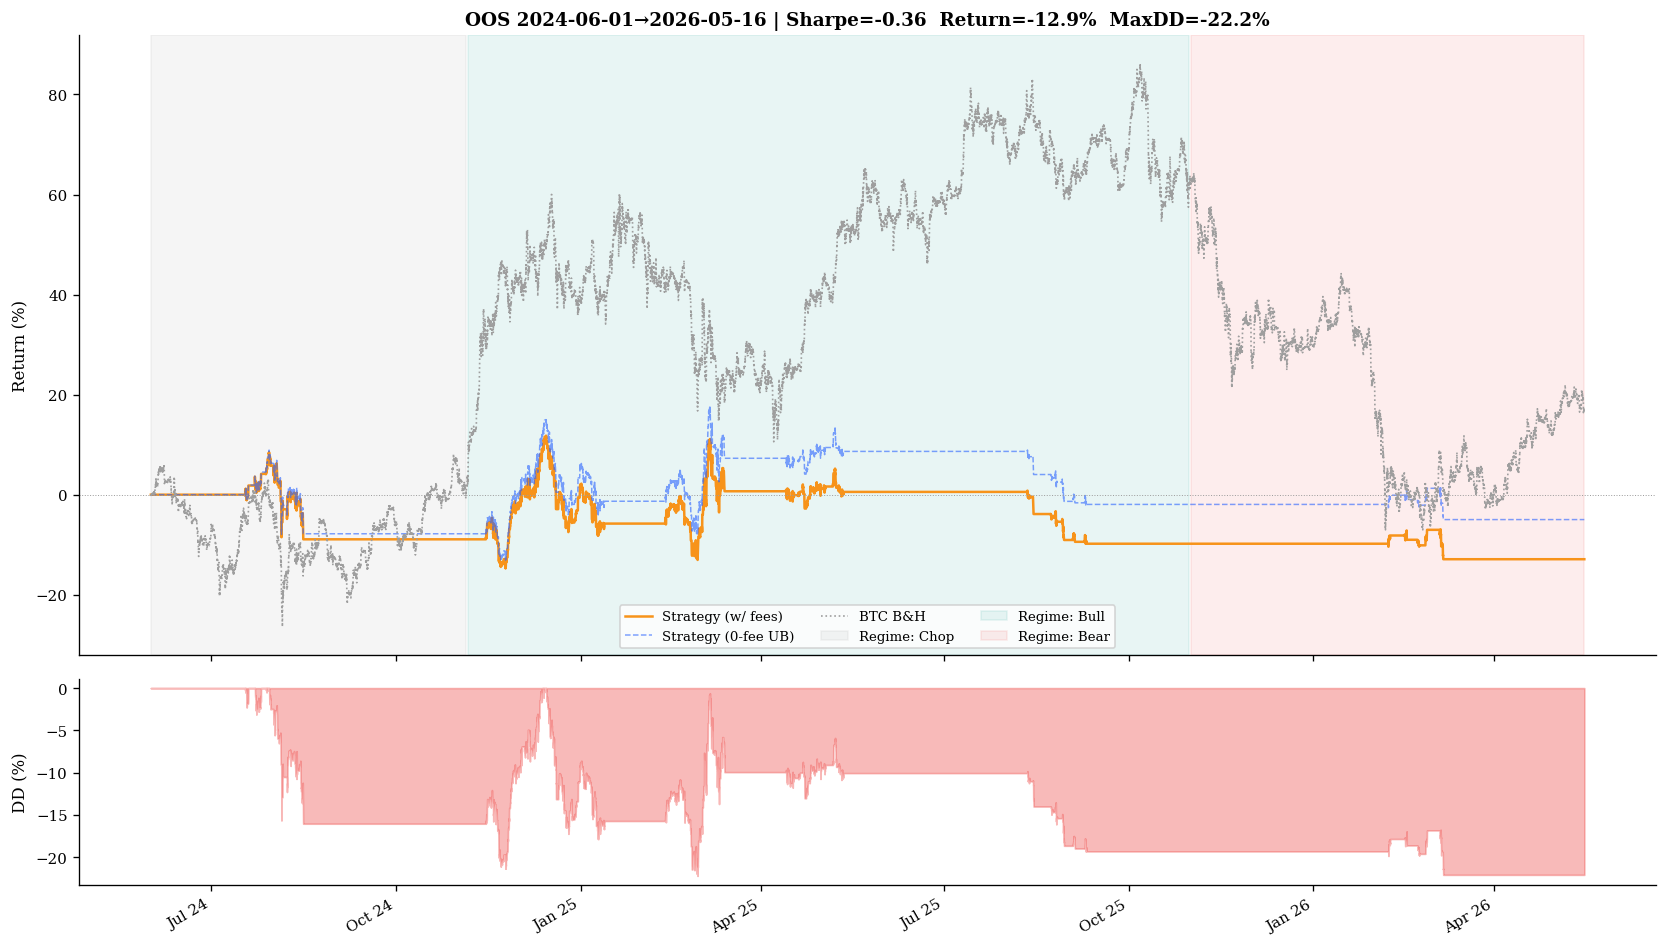

In [ ]:
# ── Regime breakdown + regime-shaded equity ──────────────────────────────────
print('=== Regime Performance Breakdown ===')
print(_regime_table(eq_fees, o_idx, oos_df['close'].values).to_string())
fig,(ax1,ax2)=plt.subplots(2,1,figsize=(14,8),height_ratios=[3,1],sharex=True)
ax1.plot(o_idx,(eq_fees-1)*100,color=ACCENT,lw=1.5,label='Strategy (w/ fees)')
ax1.plot(o_idx,(eq_0fee-1)*100,color=BLUE,lw=0.9,ls='--',alpha=0.6,label='Strategy (0-fee UB)')
ax1.plot(o_idx,bh,color=GREY,lw=1.0,ls=':',label='BTC B&H')
for rname,(rs,re),rc in [('Chop',REGIME_CHOP,'#9E9E9E'),('Bull',REGIME_BULL,'#26A69A'),('Bear',REGIME_BEAR,'#EF5350')]:
    ax1.axvspan(rs,min(re,o_idx[-1]),alpha=0.10,color=rc,label=f'Regime: {rname}')
ax1.axhline(0,color=GREY,lw=0.6,ls=':'); ax1.set_ylabel('Return (%)'); ax1.legend(fontsize=8,ncol=3)
ax1.set_title(f'OOS {OOS_START.date()}→{o_idx[-1].date()} | Sharpe={_sharpe(eq_fees):.2f}  '
    f'Return={eq_fees[-1]-1:+.1%}  MaxDD={_maxdd(eq_fees):.1%}',fontweight='bold')
pk=np.maximum.accumulate(eq_fees); dd=(eq_fees-pk)/pk*100
ax2.fill_between(o_idx,dd,0,color=RED,alpha=0.4); ax2.set_ylabel('DD (%)')
ax2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
plt.setp(ax2.xaxis.get_majorticklabels(),rotation=30,ha='right')
fig.tight_layout(); fig.savefig(ARTS_DIR/'01_equity_regime.png'); plt.show()